# Welcome to Colab!

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


259/259 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - loss: 3.6510e-05 - val_loss: 0.0019
Epoch 2/25
259/259 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - loss: 1.2328e-05 - val_loss: 8.2866e-04
Epoch 3/25
259/259 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - loss: 1.2149e-05 - val_loss: 0.0027
Epoch 4/25
259/259 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - loss: 1.0626e-05 - val_loss: 0.0011
Epoch 5/25
259/259 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - loss: 1.1499e-05 - val_loss: 0.0016
Epoch 6/25
259/259 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - loss: 9.5005e-06 - val_loss: 4.7201e-04
Epoch 7/25
259/259 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - loss: 8.5117e-06 - val_loss: 0.0012
Epoch 8/25
259/259 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - loss: 9.5955e-06 - val_loss: 0.0012
Epoch 9/25
259/259 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - loss: 1.1182e-05 - val_loss: 4.4981e-04
Epoch 10/25
259/259 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - loss: 9.2359e-06 - val_loss: 0.0011
Epoch 11/25
259/259 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - loss: 8.1804e-06 - va

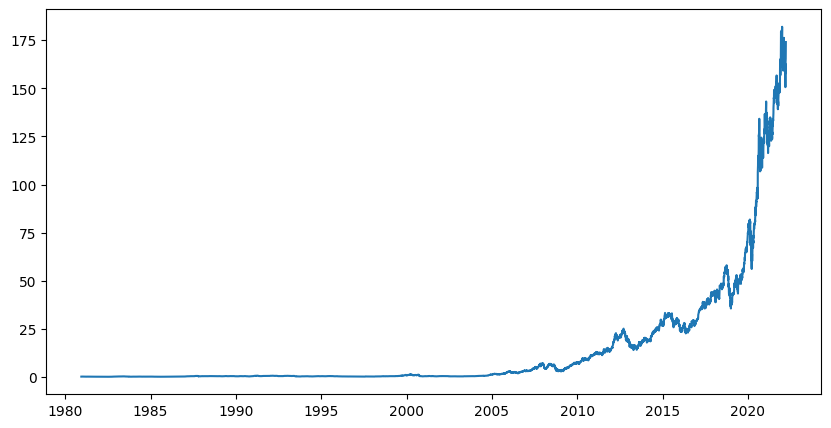

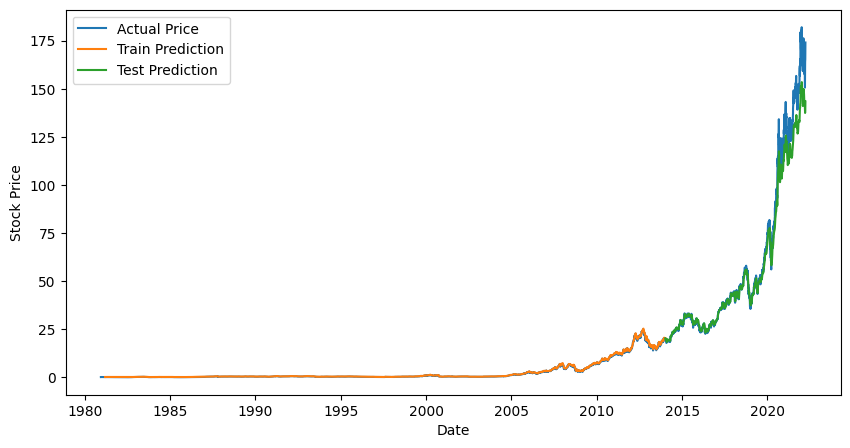

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

df = pd.read_csv("AAPL.csv")
df = df[['Date', 'Close']]
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df[['Close']])

def create_sequences(data, time_step=60):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_sequences(scaled_data, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)

train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=32
)

train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse scaling
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))
print("RMSE:", rmse)

plt.figure(figsize=(10,5))
plt.plot(df.index, df['Close'], label='Actual Price')

# Create empty arrays for plotting
train_plot = np.full((len(scaled_data), 1), np.nan)
test_plot = np.full((len(scaled_data), 1), np.nan)

# Align predictions with proper time indices
train_plot[time_step:train_size + time_step] = train_predict
test_plot[train_size + time_step:] = test_predict

# Plot with correct dates
plt.figure(figsize=(10,5))
plt.plot(df.index, scaler.inverse_transform(scaled_data), label='Actual Price')
plt.plot(df.index, train_plot, label='Train Prediction')
plt.plot(df.index, test_plot, label='Test Prediction')

plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.show()